# Relational Database Foundations

Before writing complex SQL queries, it is crucial to understand *how* data is stored and organized. Relational Database Management Systems (RDBMS) like MySQL, PostgreSQL, and SQLite have been the backbone of software and data science for decades. 

At its core, a relational database is a way of storing data in highly structured tables that "relate" to one another, preventing duplication and ensuring the data remains accurate and consistent. 

As Data Scientists, we often interact with these databases using Python. In this notebook, we will use Python libraries to visualize exactly how these database concepts work under the hood.

---

# 1. Tables, Rows, and Columns
A database is made up of multiple **Tables** (also called entities or relations). You can think of a table like a single sheet in an Excel workbook or a Pandas DataFrame.

* **Columns (Attributes/Fields)**: Define the *type* of data being stored. Every piece of data in a column must be of the same data type.
* **Rows (Records/Tuples)**: Represent a single, distinct entry in the table.

In [1]:
import pandas as pd

# Visualizing a simple 'Customers' Table using Pandas
data = {
    'customer_id': [101, 102, 103],
    'first_name': ['Alice', 'Bob', 'Charlie'],
    'email': ['alice@email.com', 'bob@email.com', 'charlie@email.com']
}
customers_table = pd.DataFrame(data)
display(customers_table)

,customer_id,first_name,email
0,101,Alice,alice@email.com
1,102,Bob,bob@email.com
2,103,Charlie,charlie@email.com


# 2. Primary Keys (PK)
A **Primary Key** is a specific column (or combination of columns) that uniquely identifies *every single row* in a table. 
* It must be **UNIQUE** (no two rows can have the same primary key).
* It cannot be **NULL** (it cannot be blank).
* *Example*: In the table above, `customer_id` is the Primary Key.

# 3. Foreign Keys (FK) & Relationships
This is where the "relational" in relational databases comes from. A **Foreign Key** is a column in one table that points to the Primary Key of another table. This creates a link between the two tables.

Let's visualize the three main types of relationships using Python's `networkx` library to draw an **Entity-Relationship (ER) Diagram**:

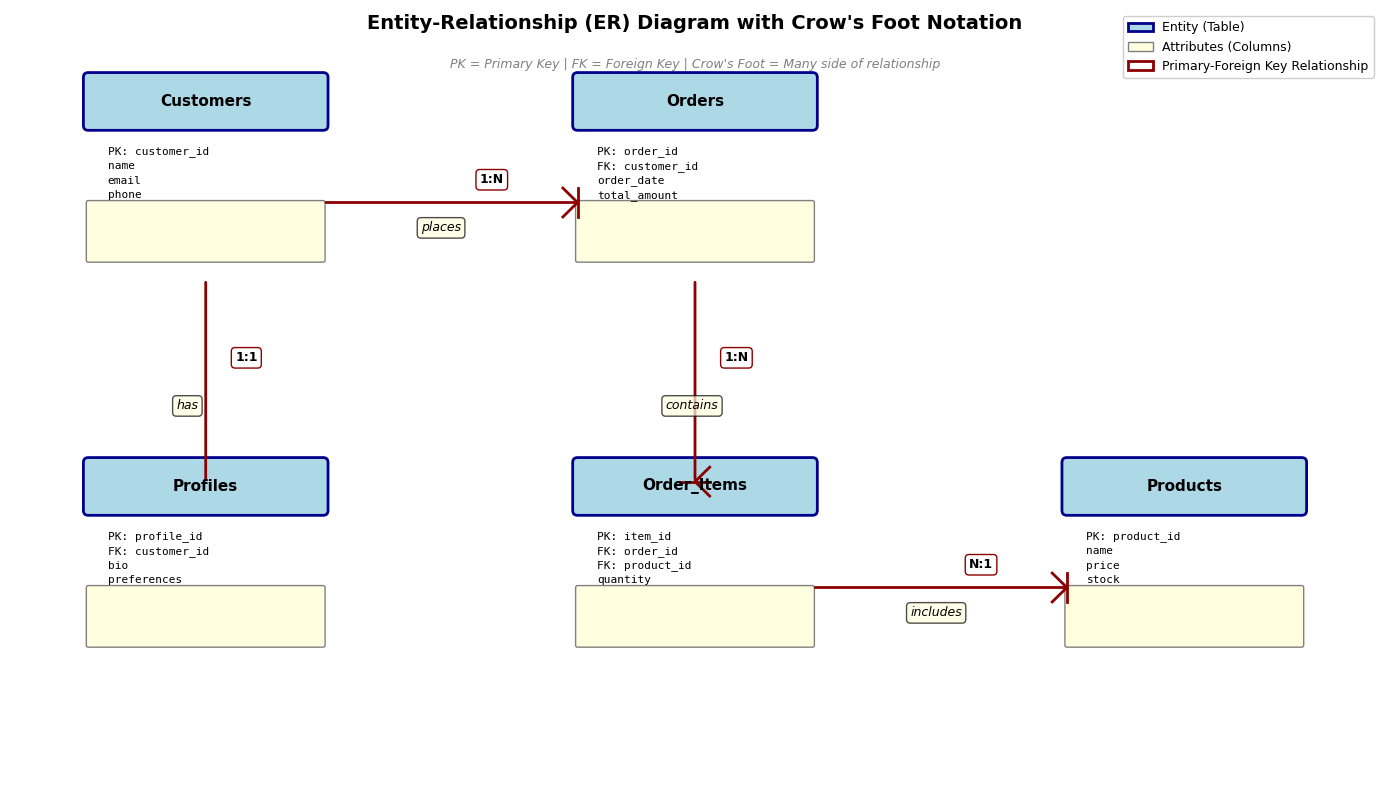

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create a more sophisticated ER Diagram with proper notation
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

# Define table positions and attributes
tables = {
    'Customers': {
        'pos': (2, 6),
        'attributes': ['PK: customer_id', 'name', 'email', 'phone']
    },
    'Orders': {
        'pos': (7, 6),
        'attributes': ['PK: order_id', 'FK: customer_id', 'order_date', 'total_amount']
    },
    'Order_Items': {
        'pos': (7, 2),
        'attributes': ['PK: item_id', 'FK: order_id', 'FK: product_id', 'quantity']
    },
    'Products': {
        'pos': (12, 2),
        'attributes': ['PK: product_id', 'name', 'price', 'stock']
    },
    'Profiles': {
        'pos': (2, 2),
        'attributes': ['PK: profile_id', 'FK: customer_id', 'bio', 'preferences']
    }
}

# Draw table boxes with attributes
for table_name, info in tables.items():
    x, y = info['pos']
    # Draw blue header box with table name
    header_box = FancyBboxPatch((x - 1.2, y + 0.8), 2.4, 0.5, 
                                boxstyle="round,pad=0.05", 
                                edgecolor='darkblue', facecolor='lightblue', linewidth=2)
    ax.add_patch(header_box)
    ax.text(x, y + 1.05, table_name, ha='center', va='center', fontweight='bold', fontsize=11)
    
    # Draw attributes box
    attr_height = 0.15 * len(info['attributes'])
    attr_box = FancyBboxPatch((x - 1.2, y - attr_height), 2.4, attr_height,
                              boxstyle="round,pad=0.02",
                              edgecolor='gray', facecolor='lightyellow', linewidth=1)
    ax.add_patch(attr_box)
    
    # Add attributes text
    for i, attr in enumerate(info['attributes']):
        attr_y = y + 0.6 - (i + 0.5) * 0.15
        ax.text(x - 1.0, attr_y, attr, ha='left', va='center', fontsize=8, family='monospace')

# Define relationships with cardinality
relationships = [
    {
        'from': ('Customers', 'Orders'),
        'from_pos': (3.2, 6),
        'to_pos': (5.8, 6),
        'cardinality': '1:N',
        'label': 'places',
        'style': 'primary-foreign'
    },
    {
        'from': ('Orders', 'Order_Items'),
        'from_pos': (7, 5.2),
        'to_pos': (7, 3.1),
        'cardinality': '1:N',
        'label': 'contains',
        'style': 'primary-foreign'
    },
    {
        'from': ('Order_Items', 'Products'),
        'from_pos': (8.2, 2),
        'to_pos': (10.8, 2),
        'cardinality': 'N:1',
        'label': 'includes',
        'style': 'primary-foreign'
    },
    {
        'from': ('Customers', 'Profiles'),
        'from_pos': (2, 5.2),
        'to_pos': (2, 3.1),
        'cardinality': '1:1',
        'label': 'has',
        'style': 'primary-foreign'
    }
]

# Draw relationship lines with crow's foot notation
for rel in relationships:
    from_pos = rel['from_pos']
    to_pos = rel['to_pos']
    cardinality = rel['cardinality']
    
    # Draw main line
    arrow = FancyArrowPatch(from_pos, to_pos, arrowstyle='-', 
                           linewidth=2, edgecolor='darkred', zorder=1)
    ax.add_patch(arrow)
    
    # Add crow's foot notation at the end
    # For M side (many)
    if 'N' in cardinality or 'M' in cardinality:
        if to_pos[1] == from_pos[1]:  # Horizontal
            # Three small lines (crow's foot)
            offset = 0.15
            ax.plot([to_pos[0], to_pos[0]], [to_pos[1] - offset, to_pos[1] + offset], 'darkred', linewidth=2)
            ax.plot([to_pos[0] - 0.15, to_pos[0]], [to_pos[1] + offset, to_pos[1]], 'darkred', linewidth=2)
            ax.plot([to_pos[0] - 0.15, to_pos[0]], [to_pos[1] - offset, to_pos[1]], 'darkred', linewidth=2)
        else:  # Vertical
            offset = 0.15
            ax.plot([to_pos[0] - offset, to_pos[0] + offset], [to_pos[1], to_pos[1]], 'darkred', linewidth=2)
            ax.plot([to_pos[0] + offset, to_pos[0]], [to_pos[1] - 0.15, to_pos[1]], 'darkred', linewidth=2)
            ax.plot([to_pos[0] + offset, to_pos[0]], [to_pos[1] + 0.15, to_pos[1]], 'darkred', linewidth=2)
    
    # Add cardinality label
    mid_x, mid_y = (from_pos[0] + to_pos[0]) / 2, (from_pos[1] + to_pos[1]) / 2
    ax.text(mid_x + 0.3, mid_y + 0.2, cardinality, fontsize=9, fontweight='bold', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
    
    # Add relationship label
    ax.text(mid_x - 0.3, mid_y - 0.3, rel['label'], fontsize=9, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

# Add legend
legend_elements = [
    mpatches.Patch(facecolor='lightblue', edgecolor='darkblue', label='Entity (Table)', linewidth=2),
    mpatches.Patch(facecolor='lightyellow', edgecolor='gray', label='Attributes (Columns)', linewidth=1),
    mpatches.Patch(facecolor='white', edgecolor='darkred', label='Primary-Foreign Key Relationship', linewidth=2),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95)

# Add title and explanation
ax.text(7, 7.8, 'Entity-Relationship (ER) Diagram with Crow\'s Foot Notation', 
        ha='center', fontsize=14, fontweight='bold')
ax.text(7, 7.4, 'PK = Primary Key | FK = Foreign Key | Crow\'s Foot = Many side of relationship', 
        ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

# 4. Constraints
Constraints are strict rules applied to columns to prevent invalid data from being saved into the database. 

* **NOT NULL**: Ensures a column cannot be left blank.
* **UNIQUE**: Ensures all values in a column are different (e.g., `email`).
* **DEFAULT**: Sets a default value if none is provided.
* **CHECK**: Ensures data meets a specific condition (e.g., `age >= 18`).

# 5. Normalization (The Basics)
Normalization is the design process of organizing a database to **reduce data redundancy** (duplication). Let's use Python to see the difference between "Unnormalized" (Excel style) and "Normalized" (Database style) data.

In [3]:
# ❌ UNNORMALIZED DATA (Bad Database Design)
# Notice how "Apple" and "Tech Corp" are repeated. If Tech Corp changes its name, we have to update multiple rows!
unnormalized_data = {
    'order_id': [1, 2, 3],
    'customer_name': ['Alice', 'Bob', 'Alice'],
    'company': ['Tech Corp', 'Design Inc', 'Tech Corp'],
    'product': ['Laptop', 'Mouse', 'Keyboard']
}
bad_table = pd.DataFrame(unnormalized_data)
print("--- Unnormalized Table (Redundant Data) ---")
display(bad_table)

# ✅ NORMALIZED DATA (Good Database Design)
# We split the data into multiple tables connected by IDs.
customers = pd.DataFrame({
    'customer_id': [101, 102],
    'customer_name': ['Alice', 'Bob'],
    'company': ['Tech Corp', 'Design Inc']
})

orders = pd.DataFrame({
    'order_id': [1, 2, 3],
    'customer_id': [101, 102, 101], # <--- This is the Foreign Key!
    'product': ['Laptop', 'Mouse', 'Keyboard']
})

print("\n--- Normalized Tables (Clean & Efficient) ---")
print("Customers Table:")
display(customers)
print("\nOrders Table:")
display(orders)

--- Unnormalized Table (Redundant Data) ---


,order_id,customer_name,company,product
0,1,Alice,Tech Corp,Laptop
1,2,Bob,Design Inc,Mouse
2,3,Alice,Tech Corp,Keyboard



--- Normalized Tables (Clean & Efficient) ---
Customers Table:


,customer_id,customer_name,company
0,101,Alice,Tech Corp
1,102,Bob,Design Inc



Orders Table:


,order_id,customer_id,product
0,1,101,Laptop
1,2,102,Mouse
2,3,101,Keyboard


## Real-World Use Case or Analogy:
Think of a Relational Database like a well-organized **E-commerce Store System**:

* **The Problem (Unnormalized Data)**: Imagine you use a single Excel sheet for everything. When Alice buys a laptop, you write down her name, her company, and the laptop. If Alice buys a keyboard the next day, you write down her name and company *again*. If Alice's company changes its name, you have to find every single row where she bought something and update it line by line. This is a nightmare.
* **The Solution (Relational Database)**:
    * You create a **`Customers` Table**: It assigns Alice a Primary Key (`customer_id: 101`) and stores her information *exactly once*.
    * You create an **`Orders` Table**: When Alice buys the laptop, you don't write down her name. You just write: "Customer `101` bought a Laptop". The `101` is a **Foreign Key**.
* **The Result**: Now, if Alice's company changes its name, you update it in exactly *one* place (the Customers table). Because the Orders table just points to her `customer_id`, every past and future order automatically points to the correct, updated company name.

---